# Weather project - Group 4 - AI1909 #

## Member: ##
To all member contributed to this, contact if want to public private information


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import openmeteo_requests
import requests_cache
import numpy as np
import plotly.express as px 
import plotly.graph_objects as go
import statsmodels.api as sm

from statsmodels.tsa.statespace.sarimax import SARIMAX
from tabulate import tabulate
from retry_requests import retry
from sklearn.preprocessing import MinMaxScaler
from plotly.subplots import make_subplots
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error 

## Data collection

In [4]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 10.823,
	"longitude": 106.6296,
	"start_date": "1940-10-19",
	"end_date": "2024-10-19",
	"hourly": ["temperature_2m", 
            	"relative_humidity_2m", 
                "dew_point_2m", 
                "apparent_temperature", 
                "precipitation", 
                "rain", 
                "pressure_msl", 
                "surface_pressure", 
                "cloud_cover", 
                "cloud_cover_low", 
                "cloud_cover_mid", 
                "cloud_cover_high", 
                "et0_fao_evapotranspiration", 
                "vapour_pressure_deficit", 
                "wind_speed_10m", 
                "wind_direction_10m", 
                "wind_gusts_10m", 
                "soil_temperature_0_to_7cm", 
                "soil_moisture_0_to_7cm"],
	"timezone": "GMT"
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_dew_point_2m = hourly.Variables(2).ValuesAsNumpy()
hourly_apparent_temperature = hourly.Variables(3).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(4).ValuesAsNumpy()
hourly_rain = hourly.Variables(5).ValuesAsNumpy()
hourly_pressure_msl = hourly.Variables(6).ValuesAsNumpy()
hourly_surface_pressure = hourly.Variables(7).ValuesAsNumpy()
hourly_cloud_cover = hourly.Variables(8).ValuesAsNumpy()
hourly_cloud_cover_low = hourly.Variables(9).ValuesAsNumpy()
hourly_cloud_cover_mid = hourly.Variables(10).ValuesAsNumpy()
hourly_cloud_cover_high = hourly.Variables(11).ValuesAsNumpy()
hourly_et0_fao_evapotranspiration = hourly.Variables(12).ValuesAsNumpy()
hourly_vapour_pressure_deficit = hourly.Variables(13).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(14).ValuesAsNumpy()
hourly_wind_direction_10m = hourly.Variables(15).ValuesAsNumpy()
hourly_wind_gusts_10m = hourly.Variables(16).ValuesAsNumpy()
hourly_soil_temperature_0_to_7cm = hourly.Variables(17).ValuesAsNumpy()
hourly_soil_moisture_0_to_7cm = hourly.Variables(18).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
	end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}
hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["dew_point_2m"] = hourly_dew_point_2m
hourly_data["apparent_temperature"] = hourly_apparent_temperature
hourly_data["precipitation"] = hourly_precipitation
hourly_data["rain"] = hourly_rain
hourly_data["pressure_msl"] = hourly_pressure_msl
hourly_data["surface_pressure"] = hourly_surface_pressure
hourly_data["cloud_cover"] = hourly_cloud_cover
hourly_data["cloud_cover_low"] = hourly_cloud_cover_low
hourly_data["cloud_cover_mid"] = hourly_cloud_cover_mid
hourly_data["cloud_cover_high"] = hourly_cloud_cover_high
hourly_data["et0_fao_evapotranspiration"] = hourly_et0_fao_evapotranspiration
hourly_data["vapour_pressure_deficit"] = hourly_vapour_pressure_deficit
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
hourly_data["wind_direction_10m"] = hourly_wind_direction_10m
hourly_data["wind_gusts_10m"] = hourly_wind_gusts_10m
hourly_data["soil_temperature_0_to_7cm"] = hourly_soil_temperature_0_to_7cm
hourly_data["soil_moisture_0_to_7cm"] = hourly_soil_moisture_0_to_7cm

hourly_dataframe = pd.DataFrame(data = hourly_data)
hourly_dataframe.to_csv('hourly_data.csv', index=False)


In [3]:
df = pd.read_csv('hourly_data.csv')
df

,date,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration,vapour_pressure_deficit,wind_speed_10m,wind_direction_10m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_moisture_0_to_7cm
0,1940-10-19 00:00:00+00:00,23.982500,93.86332,22.932499,29.274712,0.0,0.0,1011.5,1010.80240,51.000000,50.0,9.0,2.0,0.056865,0.182797,1.138420,108.435040,8.640000,25.232500,0.475
1,1940-10-19 01:00:00+00:00,25.432499,86.33415,22.982500,30.683460,0.0,0.0,1012.5,1011.80524,77.100006,80.0,8.0,1.0,0.198537,0.443843,1.609969,116.564990,10.799999,26.032500,0.474
2,1940-10-19 02:00:00+00:00,26.782500,79.95162,23.032500,32.106525,0.1,0.1,1012.6,1011.90826,46.199997,44.0,11.0,0.0,0.296745,0.705133,1.297998,146.309900,13.320000,26.982500,0.474
3,1940-10-19 03:00:00+00:00,27.932499,76.33993,23.382500,33.798973,0.1,0.1,1012.6,1011.91080,28.499998,29.0,4.0,0.0,0.429105,0.890005,1.018234,135.000100,17.280000,28.082499,0.473
4,1940-10-19 04:00:00+00:00,28.782500,75.55751,24.032500,35.696598,0.1,0.1,1012.0,1011.31320,24.599998,22.0,8.0,0.0,0.507328,0.965861,1.018234,224.999900,17.280000,29.182499,0.470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
736363,2024-10-19 19:00:00+00:00,24.011000,98.80501,23.811000,29.892818,0.0,0.0,1011.2,1010.50270,56.399998,23.0,40.0,39.0,0.000000,0.035653,0.720000,360.000000,4.680000,26.261000,0.487
736364,2024-10-19 20:00:00+00:00,24.011000,98.21219,23.711000,29.395245,0.1,0.1,1011.1,1010.40270,52.799995,24.0,21.0,62.0,0.000000,0.053341,3.710795,255.963730,5.400000,26.111000,0.487
736365,2024-10-19 21:00:00+00:00,24.061000,97.32983,23.611000,29.523697,0.0,0.0,1010.8,1010.10330,45.000000,15.0,23.0,59.0,0.000000,0.079908,2.753470,78.690100,7.920000,26.011000,0.486
736366,2024-10-19 22:00:00+00:00,23.911001,98.50711,23.661001,29.167255,0.0,0.0,1010.8,1010.10290,21.900000,6.0,19.0,17.0,0.000000,0.044276,4.379589,80.537750,6.120000,25.861000,0.486


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736368 entries, 0 to 736367
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   date                        736368 non-null  object 
 1   temperature_2m              736368 non-null  float64
 2   relative_humidity_2m        736368 non-null  float64
 3   dew_point_2m                736368 non-null  float64
 4   apparent_temperature        736368 non-null  float64
 5   precipitation               736368 non-null  float64
 6   rain                        736368 non-null  float64
 7   pressure_msl                736368 non-null  float64
 8   surface_pressure            736368 non-null  float64
 9   cloud_cover                 736368 non-null  float64
 10  cloud_cover_low             736368 non-null  float64
 11  cloud_cover_mid             736368 non-null  float64
 12  cloud_cover_high            736368 non-null  float64
 13  et0_fao_evapot

## Data processing and visualization

In [5]:
def plot_weather_data(df, start_date, end_date, freq='D', data_type='daily'):
    """
    Plots weather data based on user-specified frequency and data type.
    
    Parameters:
    - df: Pandas DataFrame containing the weather data.
    - start_date: The start date for the plot (string in 'YYYY-MM-DD' format).
    - end_date: The end date for the plot (string in 'YYYY-MM-DD' format).
    - freq: Frequency for resampling ('H' for hourly, 'D' for daily, 'W' for weekly, 'M' for monthly, 'Y' for yearly).
    - data_type: Whether to plot 'hourly' or 'daily' data.
    """
    
    # Filter data for the specified time range
    df_filtered = df.loc[start_date:end_date]
    
    # Resample data based on user-specified frequency if not plotting hourly data
    if data_type != 'hourly':
        df_filtered = df_filtered.resample(freq).agg({
            'temperature_2m': 'mean',  # Average temperature
            'precipitation': 'sum',  # Total precipitation
            'relative_humidity_2m': 'mean'  # Average humidity
        })

    # Plotting the data
    plt.figure(figsize=(14, 8))

    # Subplot 1: Temperature
    plt.subplot(3, 1, 1)
    plt.plot(df_filtered.index, df_filtered['temperature_2m'], color='orange', label='Temperature (°C)')
    plt.title(f'Temperature from {start_date} to {end_date}')
    plt.ylabel('Temperature (°C)')
    plt.legend()
    plt.grid(True)

    # Subplot 2: Precipitation
    plt.subplot(3, 1, 2)
    plt.bar(df_filtered.index, df_filtered['precipitation'], color='blue', label='Precipitation (mm)')
    plt.title(f'Precipitation from {start_date} to {end_date}')
    plt.ylabel('Precipitation (mm)')
    plt.legend()
    plt.grid(True)

    # Subplot 3: Humidity
    plt.subplot(3, 1, 3)
    plt.plot(df_filtered.index, df_filtered['relative_humidity_2m'], color='green', label='Humidity (%)')
    plt.title(f'Humidity from {start_date} to {end_date}')
    plt.ylabel('Humidity (%)')
    plt.xlabel('Date')
    plt.legend()
    plt.grid(True)

    # Adjust layout
    plt.tight_layout()

    # Show the plots
    plt.show()



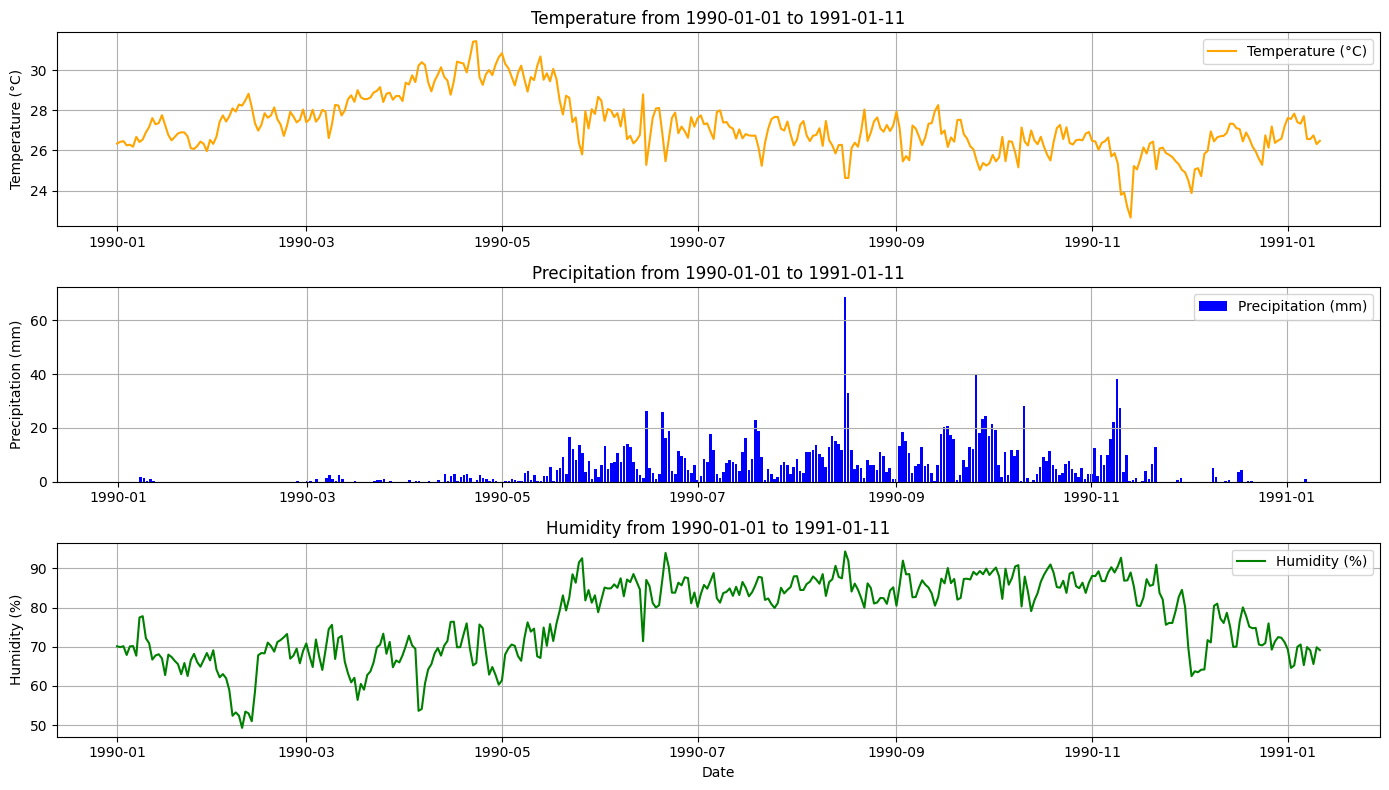

In [6]:
df = pd.read_csv('hourly_data.csv')
# Ensure 'date' is in datetime format (if not already)
df['date'] = pd.to_datetime(df['date'])

# Set 'date' as the index for easier resampling and plotting
df.set_index('date', inplace=True)

# Input for time range and aggregation
start_date = '1990-01-01'
end_date = '1991-01-11'
# Choose to plot with hourly or aggregated data
data_type = 'daily'
# Choose aggregation frequency (D for daily, W for weekly, M for monthly, Y for yearly)
freq = 'D'

# Call the plotting function
plot_weather_data(df, start_date, end_date, freq=freq, data_type=data_type)

In [13]:
df = pd.read_csv('hourly_data.csv')
df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)

# Define a custom aggregation function for each attribute
agg_dict = {
    'temperature_2m': 'mean',  # Average temperature
    'relative_humidity_2m': 'mean',  # Average humidity
    'dew_point_2m': 'mean',  # Average dew point
    'apparent_temperature': 'mean',  # Average apparent temperature
    'precipitation': 'sum',  # Total precipitation
    'rain': 'sum',  # Total rain
    'pressure_msl': 'mean',  # Average pressure at sea level
    'surface_pressure': 'mean',  # Average surface pressure
    'cloud_cover': 'mean',  # Average cloud cover
    'cloud_cover_low': 'mean',  # Average low cloud cover
    'cloud_cover_mid': 'mean',  # Average mid cloud cover
    'cloud_cover_high': 'mean',  # Average high cloud cover
    'et0_fao_evapotranspiration': 'sum',  # Total evapotranspiration
    'vapour_pressure_deficit': 'mean',  # Average vapor pressure deficit
    'wind_speed_10m': 'mean',  # Average wind speed
    'wind_direction_10m': 'mean',  # Average wind direction
    'wind_gusts_10m': 'mean',  # Average wind gusts
    'soil_temperature_0_to_7cm': 'mean',  # Average soil temperature
    'soil_moisture_0_to_7cm': 'mean'  # Average soil moisture
}

# Resample the data by month and apply the appropriate aggregation functions
monthly_data = df.resample('M').agg(agg_dict)
monthly_data.head()

C:\Users\nt_du\AppData\Local\Temp\ipykernel_195104\2344335040.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df.resample('M').agg(agg_dict)


,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration,vapour_pressure_deficit,wind_speed_10m,wind_direction_10m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_moisture_0_to_7cm
date,,,,,,,,,,,,,,,,,,,
1940-10-31 00:00:00+00:00,25.588910,87.308057,23.163109,30.743338,52.3,52.3,1012.480449,1011.785982,53.590064,35.810897,16.871795,44.240385,50.170101,0.470412,4.629395,140.950703,11.956154,27.185064,0.455513
1940-11-30 00:00:00+00:00,24.942083,87.140447,22.516666,29.566745,165.5,165.5,1009.916111,1009.221913,68.047362,36.320833,31.176389,65.688889,94.656109,0.447684,4.900365,193.831343,12.819500,26.305138,0.469631
1940-12-31 00:00:00+00:00,24.762607,82.742815,21.387540,28.762486,29.3,29.3,1012.014919,1011.318842,46.825807,23.681452,22.225806,45.612903,102.941552,0.602862,5.151893,170.259395,11.881935,25.919395,0.389888
1941-01-31 00:00:00+00:00,25.970873,75.439995,20.875040,29.433313,13.0,13.0,1011.737634,1011.044540,31.326479,14.520161,11.327957,38.618280,128.884660,0.930761,7.454230,135.532986,16.524193,27.606424,0.272930
1941-02-28 00:00:00+00:00,27.008913,72.417812,21.153259,30.563013,21.6,21.6,1012.032292,1011.341387,30.967113,16.577381,19.300595,15.255952,128.319533,1.101414,8.118138,129.316883,17.930892,29.113080,0.262269


In [12]:
print(monthly_data['temperature_2m'].mean())
print(monthly_data['temperature_2m'].max())
print(monthly_data['temperature_2m'].min())

26.785590164011218
31.09704140833333
23.40840917473118


In [10]:
# Extract 'temperature_2m' from the monthly data
temperature_data = monthly_data[['temperature_2m']].copy()

# Add 'year' and 'month' columns for grouping
temperature_data['year'] = temperature_data.index.year
temperature_data['month'] = temperature_data.index.month

# Group by year and calculate the mean temperature for each year
yearly_mean_temperature = temperature_data.groupby('year')['temperature_2m'].mean().reset_index()

# Rename columns for clarity
yearly_mean_temperature.columns = ['year', 'mean_temperature']
# Reorganize the DataFrame to only have 3 columns: year, month, and temperature_2m
temperature_df = temperature_data[['year', 'month', 'temperature_2m']].reset_index(drop=True)

temperature_df

,year,month,temperature_2m
0,1940,10,25.588910
1,1940,11,24.942083
2,1940,12,24.762607
3,1941,1,25.970873
4,1941,2,27.008913
...,...,...,...
1004,2024,6,28.267944
1005,2024,7,26.946282
1006,2024,8,27.604885
1007,2024,9,26.930375


In [11]:
fig = px.histogram(x=temperature_data['temperature_2m'], nbins=200, histnorm='density')
fig.update_layout(title='Frequency chart of temperature readings:',
                 xaxis_title='Temperature', yaxis_title='Count')

This graph provides a clear visualization of temperature frequency over 80 years, with the most common temperature being around 26.5°C. 
The data reveals a moderately stable climate with a clear peak at this temperature and a gradual decline toward more extreme values. 
The region likely enjoys a temperate or subtropical climate, where temperatures rarely fall outside the 25°C to 29°C range for most months.


In [12]:
fig = px.box(temperature_df,'month','temperature_2m')
fig.update_layout(title='Monthly temperature through years')
fig.show()

The box plot in this graph displays the monthly distribution of temperatures over an 80-year period. 
Each box represents the temperature range for a given month, with the central line inside the box showing the median temperature. 
The edges of the boxes indicate the interquartile range (IQR), which covers the middle 50% of the data, while the whiskers extend to show the variability outside the IQR. Outliers are represented by individual points. 
The plot reveals that the warmest months tend to be from May to August, with median temperatures exceeding 28°C, and the cooler months are from December to February


In [13]:
# Extract 'temperature_2m' from the monthly data
precipitation_data = monthly_data[['precipitation']].copy()

# Add 'year' and 'month' columns for grouping
precipitation_data['year'] = precipitation_data.index.year
precipitation_data['month'] = precipitation_data.index.month

# Group by year and calculate the mean temperature for each year
yearly_mean_precipitation = precipitation_data.groupby('year')['precipitation'].mean().reset_index()

# Rename columns for clarity
yearly_mean_precipitation.columns = ['year', 'mean_precipitation']

# Reorganize the DataFrame to only have 3 columns: year, month, and temperature_2m
precipitation_df = precipitation_data[['year', 'month', 'precipitation']].reset_index(drop=True)
precipitation_df

,year,month,precipitation
0,1940,10,52.3
1,1940,11,165.5
2,1940,12,29.3
3,1941,1,13.0
4,1941,2,21.6
...,...,...,...
1004,2024,6,241.8
1005,2024,7,385.9
1006,2024,8,284.8
1007,2024,9,415.7


In [14]:
fig = px.histogram(x=precipitation_df['precipitation'], nbins=200, histnorm='density')
fig.update_layout(title='Frequency chart of precipitation readings:',
                 xaxis_title='precipitation', yaxis_title='Count')

The graph reveals that the majority of months had relatively low precipitation levels, particularly between 0 and 50 mm, with a sharp decline in frequency as precipitation increases. 
This suggests that lower precipitation events are far more common than higher ones. There is also a noticeable spread of months with moderate precipitation levels (between 100 mm and 250 mm), but extreme precipitation events beyond 300 mm are rare. 
Overall, the distribution indicates a climate where low to moderate precipitation dominates, with very few occurrences of high rainfall over the period examined.


In [15]:
fig = px.box(precipitation_df,'month','precipitation')
fig.update_layout(title='Monthly precipitation through years')
fig.show()

Reading this boxplot, we can see the amount of precipitation for every month and more particularly its interval. 
This plot is basically a representation of what we know for Ho Chi Minh weather: rainy season from May to October and November then a dry season from the end of November to end of April. The data suggest it's hard to predict with more accuracy the switch. 
The plots for April and November have huge whiskers meaning a lot of variations in the attended values. For April we can notice a lot of outliers despite the size of the whisker.


In [16]:
#Yearly average temperature plot
fig = go.Figure(data=[
    go.Scatter(name='Yearly Tempratures' , x=yearly_mean_temperature['year'], y=yearly_mean_temperature['mean_temperature'], mode='lines'),
    go.Scatter(name='Yearly Tempratures' , x=yearly_mean_temperature['year'], y=yearly_mean_temperature['mean_temperature'], mode='markers')
])
fig.update_layout(title='Average temperature over the years:',
                 xaxis_title='Year', yaxis_title='Temperature')
fig.show()

#Average temperature trends over the years
fig = px.scatter(yearly_mean_temperature, x = 'year', y = 'mean_temperature', trendline = 'lowess',color='mean_temperature')
fig.update_layout(title='Average temperature trends over the years: ',
                 xaxis_title='Year', yaxis_title='Temperature')
fig.show()

With the average temperature over the years, we can conclude to a variation of 1°C over the years but we can't really predict the degree because this variation is erratic. 

However, we can figure a tendency, not surprising given the actual news and the global warming, of a rise in the average temperatures over the years. Thanks to linear regression, the visualization is very easy.


In [17]:
fig = px.scatter(temperature_df, 'month', 'temperature_2m', size='temperature_2m', animation_frame='year', range_y=[23,31],range_x=[0,13])
fig.show()

Overall, the temperature has gradually increased each year throughout the period, while the seasonal pattern has remained consistent.

Higher temperatures are typically observed during the first half of the year, with lower temperatures found towards the end. 

Notably, July serves as the turning point between the hot and cold seasons. From January, temperatures tend to rise sharply, peaking between 27-30°C in April before dropping dramatically at the turning point. 
During the cold season, temperatures stabilize around 26°C, though they can occasionally show gradual increases or decreases.


In [18]:
fig = px.scatter(precipitation_df, 'month', 'precipitation', size='precipitation', animation_frame='year', range_y=[0,500],range_x=[0,13])
fig.show()

In terms of precipitation, overall levels fluctuate but mostly converge from June to November, indicating a distinct wet season. 

Similar to temperature trends, precipitation has shown a gradual increase over the years. 
In comparing temperature and precipitation, we observe that higher temperatures are generally associated with less rainfall; however, in December, despite the lower temperatures, the amount of rainfall recorded was not significant.

- 8/2020 - 2/2021: La Niña

    During this period, the seasonal pattern in precipitation remained consistent, but temperatures decreased, with a high of 28.9°C and a low of 26.1°C, indicating that temperatures were stable around 27°C throughout the La Niña event. The increased rainfall associated with La Niña contributed to a cooler overall climate during this time.

- 5/1997 - 6/1998: El Niño

    On the other hand, the El Niño event during this period was characterized by warmer temperatures and drier conditions. Average temperatures rose, peaking higher than usual, while precipitation levels significantly dropped, leading to potential drought conditions. This lack of rainfall during the El Niño event highlighted the inverse relationship between temperature and precipitation, as the warmer conditions were not conducive to significant rainfall.


In [19]:
fig = px.line(temperature_df, 'year', 'temperature_2m', facet_col='month', facet_col_wrap=3)
fig.update_layout(title='Average temperature of every month over the years:')
fig.show()

This represents the average temperature of every month over the years. We can see that the curves in December, January, February, March, April and May are very fluctuating compared to the other months. Those months correspond to the dry season and the others to the rainy one in Ho Chi Minh.  

The dry season changes a lot depending on the year. Here are possible explanations: cold and warm air masses are not the same every year and have a big impact on the weather. Climatic events like El Niño and La Niña, which are abnormal cooling and warming, happened some years ago. 

Extreme weather events, such as storms or heatwaves, can also disrupt the usual patterns of air masses and introduce variations from one year to another.For the rainy season, the monsoon winds bring regular rains during this period, creating a relatively predictable pattern of precipitation from year to year. It is also less affected by events like El Niño, which contributes to greater stability.


In [20]:
fig = px.line(precipitation_df, 'year', 'precipitation', facet_col='month', facet_col_wrap=3)
fig.update_layout(title='Average precipitation of every month over the years:')
fig.show()

This represents the average precipitation of every month over the years. The curve is close to 0 in December, January, February and March, which is normal because it's the dry season. Curves of November and April are a bit higher because it's the transition between the dry and rainy season.

For the other months, curves are very fluctuating over the years, here are some explanations : the temperature of the ocean surface and ocean currents can influence precipitation patterns. Variations in water temperature can affect humidity and cloud formation.


### Correlation Matrix ###

<Axes: >

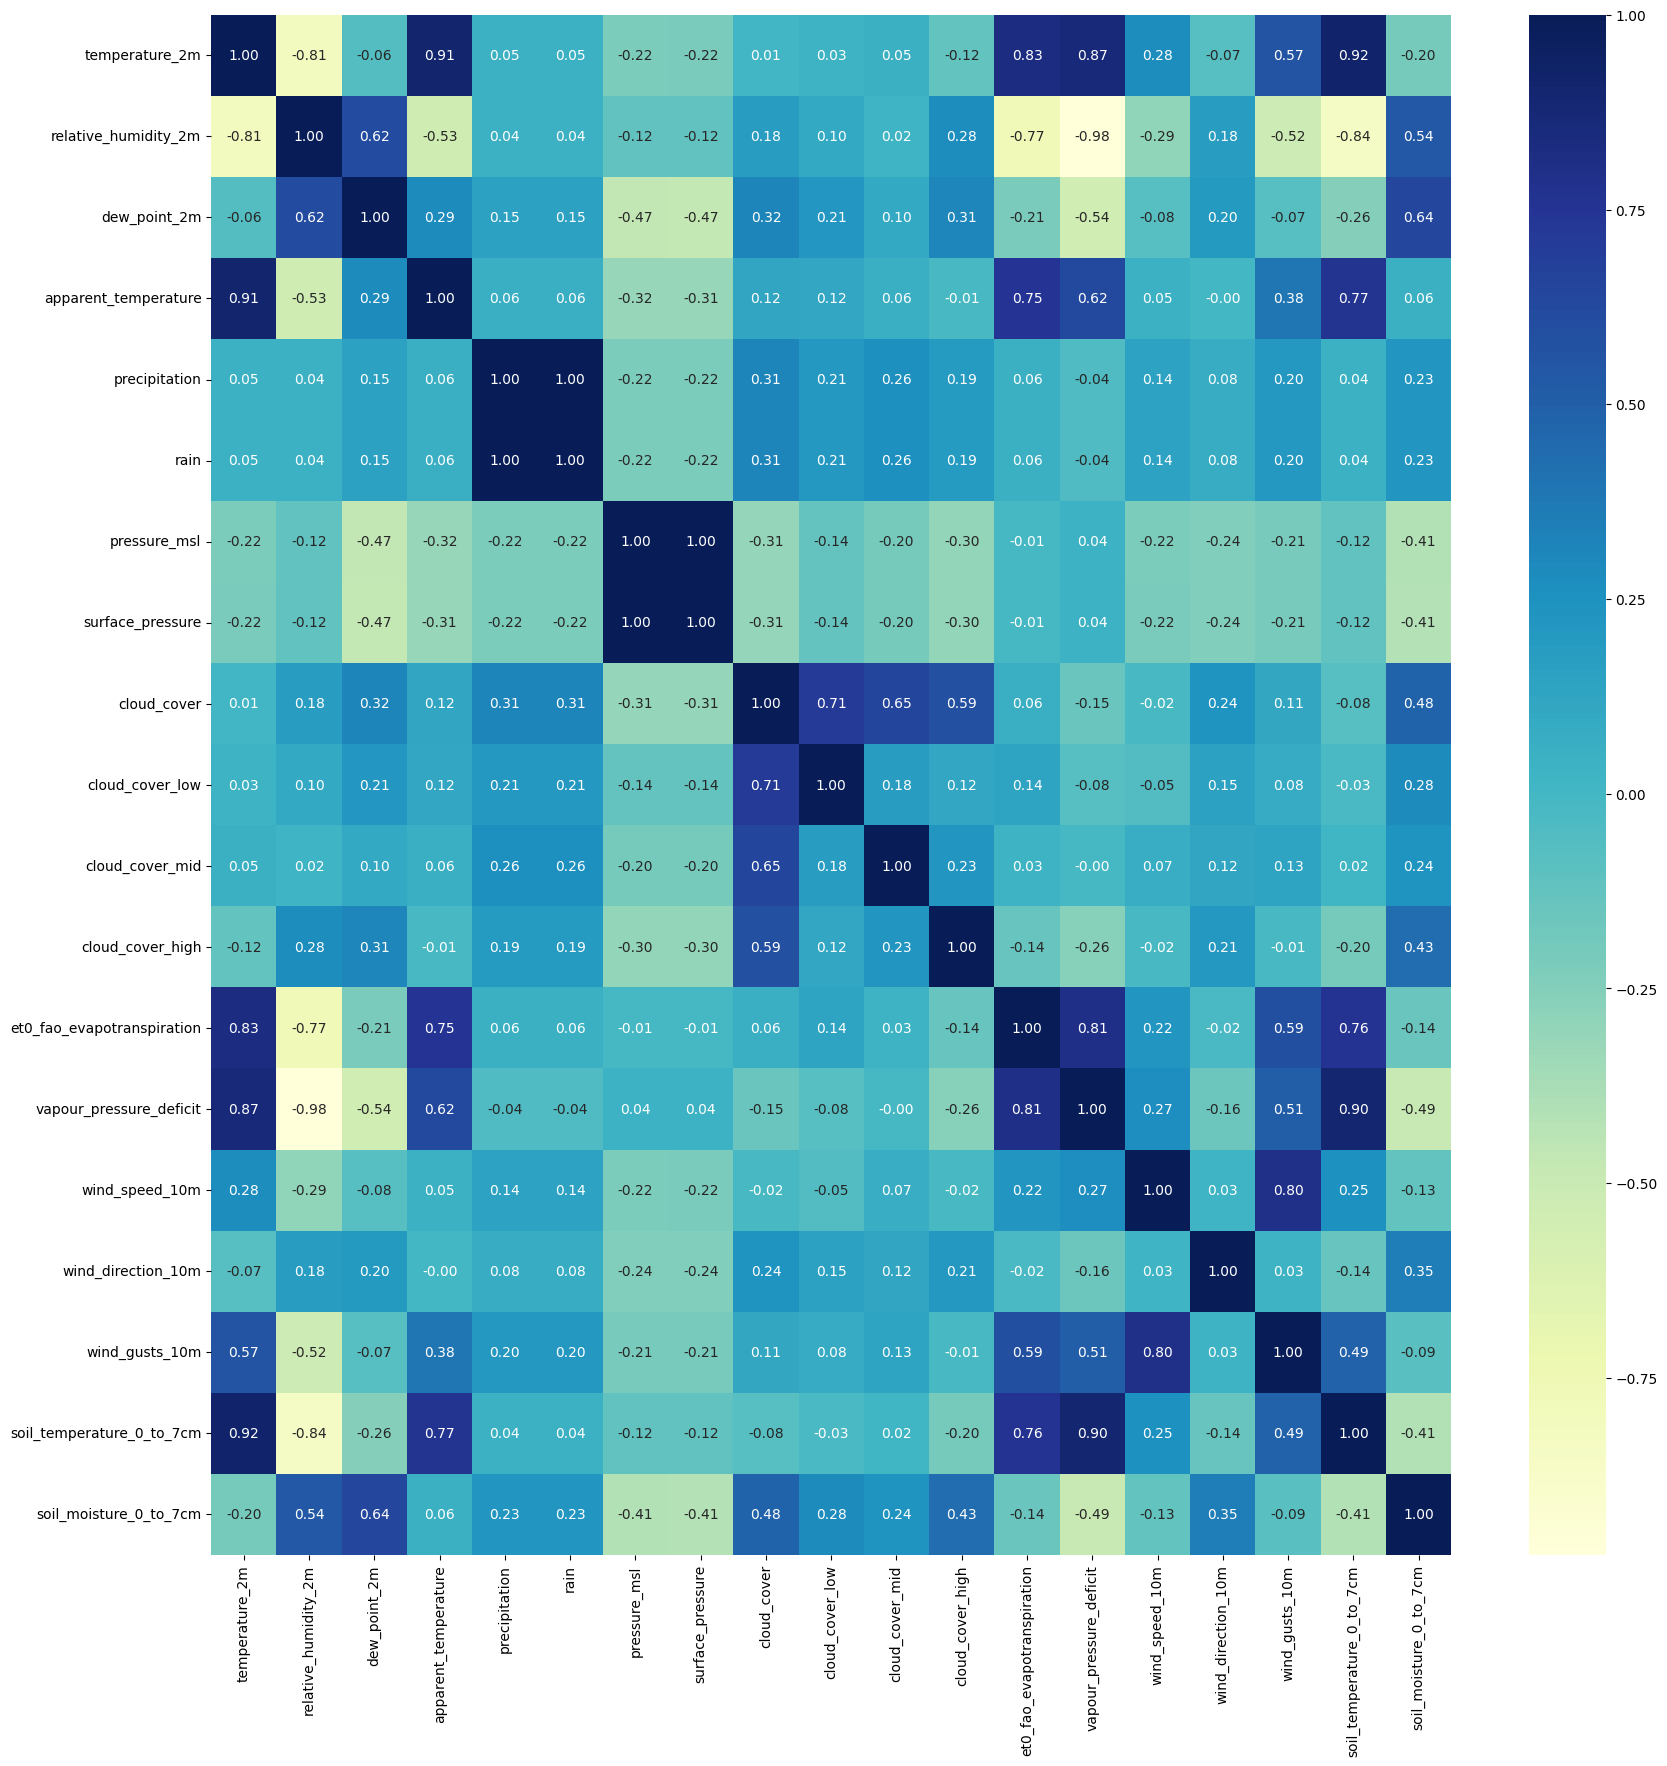

In [22]:
corr =df.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr,annot=True,fmt='.2f',cmap="YlGnBu")

This heatmap allows us to visually inspect the correlations between various weather factors. By identifying the strongest correlations, we can pinpoint the key elements influencing temperature and precipitation. This information is crucial for developing a more efficient model by including only the most relevant variables.
Based on the heatmap, the following factors have the most significant impact on:

- Temperature: soil temperature at the surface, apparent temperature, vapor pressure deficit, reference evapotranspiration, relative humidity, and wind gusts.

- Precipitation: cloud cover at both the surface and middle layers, and soil moisture at the surface.

## Weather forecasting using algorithms

Using Decision Tree Regression algorithm for prediction and evaluate the result using R2 Score, Mean Absolute Error and Mean Squared Error

In [68]:
df2 = df[["temperature_2m", "relative_humidity_2m", "dew_point_2m", "apparent_temperature", "precipitation", "rain", "pressure_msl", "surface_pressure", "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high", "et0_fao_evapotranspiration", "vapour_pressure_deficit", "wind_speed_10m", "wind_direction_10m", "wind_gusts_10m", "soil_temperature_0_to_7cm", "soil_moisture_0_to_7cm"]].copy()
df2 = pd.get_dummies(df2)
y = df2[['temperature_2m']]
x = df2.drop(columns='temperature_2m')

dtr = DecisionTreeRegressor()
train_x, test_x, train_y, test_y = train_test_split(x,y,test_size=0.3)
dtr.fit(train_x, train_y)
pred = dtr.predict(test_x)

In [69]:
# Evaluate the performance
r2 = r2_score(test_y, pred)
mae = mean_absolute_error(test_y, pred)
mse = mean_squared_error(test_y, pred)

print(f'R² Score: {r2:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')

R² Score: 0.9991
Mean Absolute Error (MAE): 0.0408
Mean Squared Error (MSE): 0.0078


Using Multiple Linear Regression algorithm for prediction and evaluate the result using R2 Score, Mean Absolute Error and Mean Squared Error

In [71]:
df2 = df[["temperature_2m", "relative_humidity_2m", "dew_point_2m", "apparent_temperature", "precipitation", "rain", "pressure_msl", "surface_pressure", "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high", "et0_fao_evapotranspiration", "vapour_pressure_deficit", "wind_speed_10m", "wind_direction_10m", "wind_gusts_10m", "soil_temperature_0_to_7cm", "soil_moisture_0_to_7cm"]].copy()
df2 = pd.get_dummies(df2)
y = df2[['temperature_2m']]
x = df2.drop(columns='temperature_2m')

mlr = LinearRegression()
train_x, test_x, train_y, test_y = train_test_split(x,y,test_size=0.3)
mlr.fit(train_x, train_y)
pred = mlr.predict(test_x)

In [72]:
# Evaluate the performance
r2 = r2_score(test_y, pred)
mae = mean_absolute_error(test_y, pred)
mse = mean_squared_error(test_y, pred)

# Print the evaluation results
print(f'R² Score: {r2:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')

R² Score: 0.9998
Mean Absolute Error (MAE): 0.0337
Mean Squared Error (MSE): 0.0017


- Comparing two Regression models, we can see that the R2 Score of both models are very high, but the MLR is higher and it is possibly an overfit case. When looking at the visualization of both, the predicted values of DTR are more scattered and the residuals have larger differences, while the values of MLR are very close to the perfect line and the zero error line. In this situation, DTR model might be a better choice for predicting weather because it’s not overfit to a specific dataset and the variances are acceptable.

Using SARIMA algorithm for temperature and precipitation prediction and comparing with recent years

In [23]:
temperature_data = monthly_data['temperature_2m']

# Fit a SARIMA model (p, d, q) are ARIMA parameters, (P, D, Q, S) are seasonal parameters
model = SARIMAX(temperature_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_model = model.fit()

# Forecast for the next 24 months
forecast_steps = 24
forecast = sarima_model.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(temperature_data.index[-1], periods=forecast_steps+1, freq='M')[1:]
forecast_mean = forecast.predicted_mean


# Display the forecasted values
forecast_T_df = pd.DataFrame({'Date': forecast_index, 'Forecasted Temperature': forecast_mean})
print(forecast_T_df)

                                               Date  Forecasted Temperature
2024-11-30 00:00:00+00:00 2024-11-30 00:00:00+00:00               26.693912
2024-12-31 00:00:00+00:00 2024-12-31 00:00:00+00:00               26.499219
2025-01-31 00:00:00+00:00 2025-01-31 00:00:00+00:00               26.803172
2025-02-28 00:00:00+00:00 2025-02-28 00:00:00+00:00               27.737718
2025-03-31 00:00:00+00:00 2025-03-31 00:00:00+00:00               28.871725
2025-04-30 00:00:00+00:00 2025-04-30 00:00:00+00:00               29.476899
2025-05-31 00:00:00+00:00 2025-05-31 00:00:00+00:00               28.783758
2025-06-30 00:00:00+00:00 2025-06-30 00:00:00+00:00               27.751610
2025-07-31 00:00:00+00:00 2025-07-31 00:00:00+00:00               27.275244
2025-08-31 00:00:00+00:00 2025-08-31 00:00:00+00:00               27.267059
2025-09-30 00:00:00+00:00 2025-09-30 00:00:00+00:00               26.955854
2025-10-31 00:00:00+00:00 2025-10-31 00:00:00+00:00               26.750356
2025-11-30 0

C:\Users\nt_du\AppData\Local\Temp\ipykernel_163416\679963235.py:10: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



In [24]:
forecast_T_df['Forecasted Temperature'].mean()

27.57779254579961

In [25]:
yearly_mean_temperature

,year,mean_temperature
0,1940,25.097867
1,1941,26.221986
2,1942,26.128850
3,1943,25.591763
4,1944,26.413053
...,...,...
80,2020,27.752295
81,2021,27.202179
82,2022,27.100551
83,2023,27.513066


In [26]:
fig = px.scatter(forecast_T_df, 'Date', 'Forecasted Temperature',size='Forecasted Temperature',range_y=[23,31])
fig_original = px.scatter(temperature_df, 'month', 'temperature_2m', size='temperature_2m', animation_frame='year', range_y=[23,32],range_x=[0,13])
fig.show()
fig_original.show()

The forecasted temperature trends in the chart closely resemble the general weather patterns in Ho Chi Minh City. The forecasted temperature from the chart shows values between 26°C and 29°C throughout the year, which aligns with the typical temperature range in Ho Chi Minh City.

- Dry Season (Dec - Apr): The forecasted temperatures start low around 26°C in January, gradually increasing to a peak in May (around 29°C). This matches the general trend in Ho Chi Minh City, where the hottest months occur just before the wet season (April-May).
- Wet Season (May - Nov): After the peak in May, the temperature in the chart declines through the middle of the year (July) and levels off towards the end (November). In Ho Chi Minh City, while temperatures remain relatively high during the wet season, the city experiences a slight cooling effect due to increased cloud cover and rainfall, which aligns with the gradual temperature decrease in the chart.

In [27]:
# Extract the 'precipitation' column from the monthly data
precipitation_data = monthly_data['precipitation']

# Fit a SARIMA model (p, d, q) are ARIMA parameters, (P, D, Q, S) are seasonal parameters
# SARIMA order should be tuned for best results
model = SARIMAX(precipitation_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))

sarima_model = model.fit()

# Forecast for the next 24 months
forecast_steps = 24
forecast = sarima_model.get_forecast(steps=forecast_steps)

# Get the predicted mean and confidence intervals
forecast_index = pd.date_range(precipitation_data.index[-1], periods=forecast_steps+1, freq='M')[1:]
forecast_mean = forecast.predicted_mean

# Display the forecasted precipitation values
forecast_P_df = pd.DataFrame({'Date': forecast_index, 'Forecasted Precipitation': forecast_mean})
print(forecast_P_df)

                                               Date  Forecasted Precipitation
2024-11-30 00:00:00+00:00 2024-11-30 00:00:00+00:00                139.304908
2024-12-31 00:00:00+00:00 2024-12-31 00:00:00+00:00                 67.811888
2025-01-31 00:00:00+00:00 2025-01-31 00:00:00+00:00                 35.394483
2025-02-28 00:00:00+00:00 2025-02-28 00:00:00+00:00                 27.437934
2025-03-31 00:00:00+00:00 2025-03-31 00:00:00+00:00                 40.286617
2025-04-30 00:00:00+00:00 2025-04-30 00:00:00+00:00                 86.946896
2025-05-31 00:00:00+00:00 2025-05-31 00:00:00+00:00                209.232459
2025-06-30 00:00:00+00:00 2025-06-30 00:00:00+00:00                254.506022
2025-07-31 00:00:00+00:00 2025-07-31 00:00:00+00:00                275.968681
2025-08-31 00:00:00+00:00 2025-08-31 00:00:00+00:00                280.443445
2025-09-30 00:00:00+00:00 2025-09-30 00:00:00+00:00                325.978924
2025-10-31 00:00:00+00:00 2025-10-31 00:00:00+00:00             

C:\Users\nt_du\AppData\Local\Temp\ipykernel_163416\2455200601.py:15: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



In [28]:
forecast_P_df['Forecasted Precipitation'].mean()

168.55748463487112

In [29]:
yearly_mean_precipitation

,year,mean_precipitation
0,1940,82.366667
1,1941,170.066667
2,1942,131.358333
3,1943,158.733333
4,1944,139.958333
...,...,...
80,2020,180.408333
81,2021,194.441667
82,2022,213.050000
83,2023,207.433333


In [30]:
fig = px.scatter(forecast_P_df, 'Date', 'Forecasted Precipitation',size='Forecasted Precipitation',range_y=[0,500])
fig_original = px.scatter(precipitation_df, 'month', 'precipitation', size='precipitation', animation_frame='year', range_y=[0,500],range_x=[0,13])
fig.show()
fig_original.show()

This forecasted precipitation pattern aligns well with the typical tropical climate of Ho Chi Minh City, where the wet season brings heavy rainfall during the middle and late months of the year, and the dry season spans from late fall to early spring with very little precipitation.
- Dry Season: From December to April, rainfall is minimal in HCM, similar to what we see in the chart where precipitation is low during these months.
- Wet Season: From May to November, the city experiences heavy rainfall, especially from June to September, aligning with the chart's sharp rise in precipitation starting around June and peaking in September.